In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

##data_path = "/Users/nika/Desktop/Tor/raw"
MY_IP = "192.168.0.74"
MAX_LEN = 2000

In [2]:
dataF = np.load("/Users/nika/Desktop/Tor/raw/tor_time_test2w_200w_100tr.npz", allow_pickle=True)
print(dataF.files)

['data', 'labels']


In [3]:
print("dataF keys:", dataF.files)

dataF keys: ['data', 'labels']


In [4]:
# Load arrays
X_F = dataF['data']
y_F = dataF['labels']

print("Total X shape:", X_F)
print("Total y shape:", y_F)

Total X shape: [[ 1  1  1 ... -1 -1 -1]
 [ 1  1 -1 ... -1 -1 -1]
 [-1  1  1 ... -1  1  1]
 ...
 [ 1  1 -1 ...  0  0  0]
 [-1  1  1 ...  0  0  0]
 [ 1  1 -1 ...  0  0  0]]
Total y shape: ['9gag.com' '9gag.com' '9gag.com' ... 'zippyshare.com' 'zippyshare.com'
 'zippyshare.com']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_F,
    y_F,
    test_size=0.2,
    random_state=42,
    stratify=y_F
)
X_train_small=X_train.astype(np.float32)
X_test_small=X_test.astype(np.float32)
print("Train:", X_train_small.shape)
print("Test:", X_test_small.shape)

Train: (16000, 5000)
Test: (4000, 5000)


In [2]:
import numpy as np

# Загружаем npz
dataF = np.load("/Users/nika/Desktop/Tor/raw/tor_200w_2500tr.npz", allow_pickle=True)

# Посмотреть, какие ключи есть
print("Keys in NPZ file:", dataF.files)

# Обычно есть 'data' и 'labels'
X = dataF['data']      # признаки
y = dataF['labels']    # метки / сессии

# Размерность данных
print("Shape of X (samples, features):", X.shape)
print("Shape of y (samples,):", y.shape)

# Количество файлов / сессий
# Если y — числовые метки сессий:
n_sessions = len(np.unique(y))
print("Number of sessions/classes:", n_sessions)

# Количество признаков
n_features = X.shape[1]
print("Number of features:", n_features)

# Количество записей / файлов
n_samples = X.shape[0]
print("Number of samples/files:", n_samples)

Keys in NPZ file: ['data', 'labels']
Shape of X (samples, features): (500000, 5000)
Shape of y (samples,): (500000,)
Number of sessions/classes: 200
Number of features: 5000
Number of samples/files: 500000


In [45]:
rf_npz1 = RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

rf_npz1.fit(X_train_small, y_train)

y_pred_rf_npz1 = rf_npz1.predict(X_test_small)

acc_rf_npz1 = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf_npz1)

Random Forest Accuracy: 0.71114


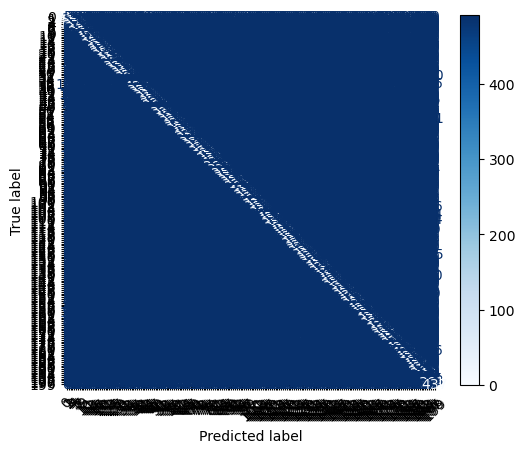

In [42]:
cm_npz1 = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_npz1
)

disp.plot(xticks_rotation=45, cmap="Blues")
plt.show()

In [46]:
precision_npz1_rf = precision_score(y_test, y_pred_rf_npz1, average='weighted')
recall_npz1_rf = recall_score(y_test, y_pred_rf_npz1, average='weighted')
f1_npz1_rf = f1_score(y_test, y_pred_rf_npz1, average='weighted')

print("Random Forest Precision:", precision_npz1_rf)
print("Random Forest Recall:", recall_npz1_rf)
print("Random Forest F1 Score:", f1_npz1_rf)


Random Forest Precision: 0.7302783823819717
Random Forest Recall: 0.71114
Random Forest F1 Score: 0.7017996126249845


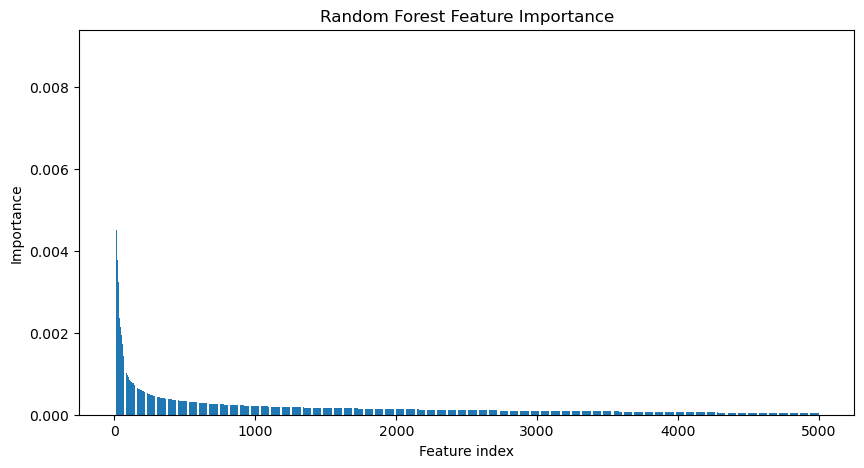

In [47]:
# Feature Importance
import matplotlib.pyplot as plt

importances = rf_npz1.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.title("Random Forest Feature Importance")
plt.bar(range(X_train_small.shape[1]), importances[indices])
plt.xlabel("Feature index")
plt.ylabel("Importance")
plt.show()

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_npz1 = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

svm_npz1.fit(X_train_scaled, y_train)

y_pred_svm_npz1 = svm_npz1.predict(X_test_scaled)

acc_svm_npz1 = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm_npz1)

In [ ]:
cm_svm_npz1 = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm_npz1
)

disp.plot(xticks_rotation=45, cmap="Blues")
plt.show()

In [ ]:
# Encode labels
le = LabelEncoder()

y_encoded = le.fit_transform(y_all)

num_classes = len(np.unique(y_encoded))

y_cnn = to_categorical(
    y_encoded,
    num_classes=num_classes
)

# Split again
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Reshape for CNN
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [ ]:
model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu',
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(
    MaxPooling1D(pool_size=2)
)

model.add(Flatten())

model.add(
    Dense(64, activation='relu')
)

model.add(
    Dense(num_classes, activation='softmax')
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

In [ ]:
loss, acc_cnn = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("CNN Accuracy:", acc_cnn)

In [ ]:
y_pred_cnn = model.predict(X_test)

y_pred_labels = np.argmax(y_pred_cnn, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

precision = precision_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

recall = recall_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

print("CNN Precision:", precision)
print("CNN Recall:", recall)